In [43]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [44]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [45]:
df=pd.read_csv('/content/drive/MyDrive/USD_TRY Geçmiş Verileri (3).csv')

In [46]:
df.head()

,Tarih,Şimdi,Açılış,Yüksek,Düşük,Hac.,Fark %
0,01.04.2026,"44,4799","44,4418","44,4911","44,4514",NaN,"0,06%"
1,31.03.2026,"44,4537","44,4567","44,6085","44,2667",NaN,"0,04%"
2,30.03.2026,"44,4347","44,4401","44,5846","44,2398",NaN,"-0,05%"
3,29.03.2026,"44,4577","44,4380","44,4703","44,4300",NaN,"0,06%"
4,27.03.2026,"44,4300","44,3470","44,6170","44,2091",NaN,"0,23%"


In [47]:
df.columns=['Date','Price','Open','High','Low','Volume','Change']

In [48]:
df.head()

,Date,Price,Open,High,Low,Volume,Change
0,01.04.2026,"44,4799","44,4418","44,4911","44,4514",NaN,"0,06%"
1,31.03.2026,"44,4537","44,4567","44,6085","44,2667",NaN,"0,04%"
2,30.03.2026,"44,4347","44,4401","44,5846","44,2398",NaN,"-0,05%"
3,29.03.2026,"44,4577","44,4380","44,4703","44,4300",NaN,"0,06%"
4,27.03.2026,"44,4300","44,3470","44,6170","44,2091",NaN,"0,23%"


In [49]:
#Tarihi datetime yap
df['Date']=pd.to_datetime(df['Date'],dayfirst=True)

In [50]:
#Virgülleri Noktaya çevir
for col in ['Price','Open','High','Low']:
  df[col]=df[col].astype(str).str.replace(',','.').astype(float)


In [51]:
df.shape

(786, 7)

In [52]:
df.head()

,Date,Price,Open,High,Low,Volume,Change
0,2026-04-01,44.4799,44.4418,44.4911,44.4514,NaN,"0,06%"
1,2026-03-31,44.4537,44.4567,44.6085,44.2667,NaN,"0,04%"
2,2026-03-30,44.4347,44.4401,44.5846,44.2398,NaN,"-0,05%"
3,2026-03-29,44.4577,44.4380,44.4703,44.4300,NaN,"0,06%"
4,2026-03-27,44.4300,44.3470,44.6170,44.2091,NaN,"0,23%"


In [53]:
#Gerekli sütunlar
df=df[['Date','Price']]

In [54]:
#Tarihe göre artan sırala
df=df.sort_values('Date')

In [55]:
df.head()

,Date,Price
785,2023-03-30,19.1676
784,2023-03-31,19.1582
783,2023-04-03,19.1749
782,2023-04-04,19.2062
781,2023-04-05,19.2394


In [56]:
#Date sütununu index yap
df.set_index('Date',inplace=True)

In [57]:
print(df.head())
print(df.tail())

              Price
Date               
2023-03-30  19.1676
2023-03-31  19.1582
2023-04-03  19.1749
2023-04-04  19.2062
2023-04-05  19.2394
              Price
Date               
2026-03-27  44.4300
2026-03-29  44.4577
2026-03-30  44.4347
2026-03-31  44.4537
2026-04-01  44.4799


In [58]:
#Eğitim ve Test verisini ayırma
son_tarih=df.index.max()
baslangic_test=son_tarih - pd.DateOffset(months=6)

train=df[df.index< baslangic_test]
test=df[df.index>=baslangic_test]

print("Egitim boyutu: ",train.shape)
print("Test boyutu: ",test.shape)
print("Test başlangıç tarihi: ",test.index.min())
print("Test bitiş tarihi: ",test.index.max())

Egitim boyutu:  (654, 1)
Test boyutu:  (132, 1)
Test başlangıç tarihi:  2025-10-01 00:00:00
Test bitiş tarihi:  2026-04-01 00:00:00


In [59]:
train.head()

,Price
Date,
2023-03-30,19.1676
2023-03-31,19.1582
2023-04-03,19.1749
2023-04-04,19.2062
2023-04-05,19.2394


In [60]:
test.head()

,Price
Date,
2025-10-01,41.5672
2025-10-02,41.6048
2025-10-03,41.6932
2025-10-06,41.6900
2025-10-07,41.7013


In [79]:
#Minmax scaler
scaler=MinMaxScaler(feature_range=(0,1))

#Fit scaler sadece eğitim verisine
train_scaled=scaler.fit_transform(train)

#Test verisi scaler ile dönüştür(fit etmiyoruz ,eğitimden öğrendik)
#test verisini fit edersek model test  verisi ile ilgili bilgi edinmiş olur
test_scaled=scaler.transform(test)

print("train_scaled shape: ",train_scaled.shape)
print("test_scaled shape: ",test_scaled.shape)

train_scaled shape:  (654, 1)
test_scaled shape:  (132, 1)


In [81]:
import numpy as np

def create_sequences(data, window_size):
    """
    data: normalize edilmiş numpy array (train_scaled veya test_scaled)
    window_size: kaç gün geriye bakacağını belirtir
    """
    X = []
    y = []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])  # son 'window_size' gün
        y.append(data[i, 0])                # tahmin edilecek gün
    X = np.array(X)
    y = np.array(y)
    return X, y

window_size = 20

# Train ve test setleri için
X_train, y_train = create_sequences(train_scaled, window_size)
X_test, y_test = create_sequences(test_scaled, window_size)

# LSTM input shape = (samples, time_steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (634, 20, 1)
X_test shape: (112, 20, 1)


In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [93]:
#MODEL
model=Sequential()
model.add(LSTM(100,return_sequences=True,input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.3))
model.add(LSTM(70))
model.add(Dropout(0.3))
model.add(Dense(20,activation='relu'))
model.add(Dense(1))

#Compile

model.compile(optimizer='adam', loss='mse')

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [94]:
# Eğit
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0297 - val_loss: 0.0052
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0268 - val_loss: 0.0098
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0165 - val_loss: 0.0031
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0088 - val_loss: 4.7183e-04
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0053 - val_loss: 2.0652e-04
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0050 - val_loss: 8.7634e-04
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - val_loss: 3.7688e-04
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0039 - val_loss: 2.7791e-04
Epoch 9/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0028 - val_loss: 0.0032
Epoch 10/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0032 - val_loss: 1.1255e-04
Epoch 11/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0034 - val_loss: 8.0638e-04
Epoch 12/30
18/18 ━━━━━━━━━━━━━━━━━

In [95]:
# Test seti tahmini
y_pred_scaled = model.predict(X_test)

# Orijinal scale'e geri döndür
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1,1))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


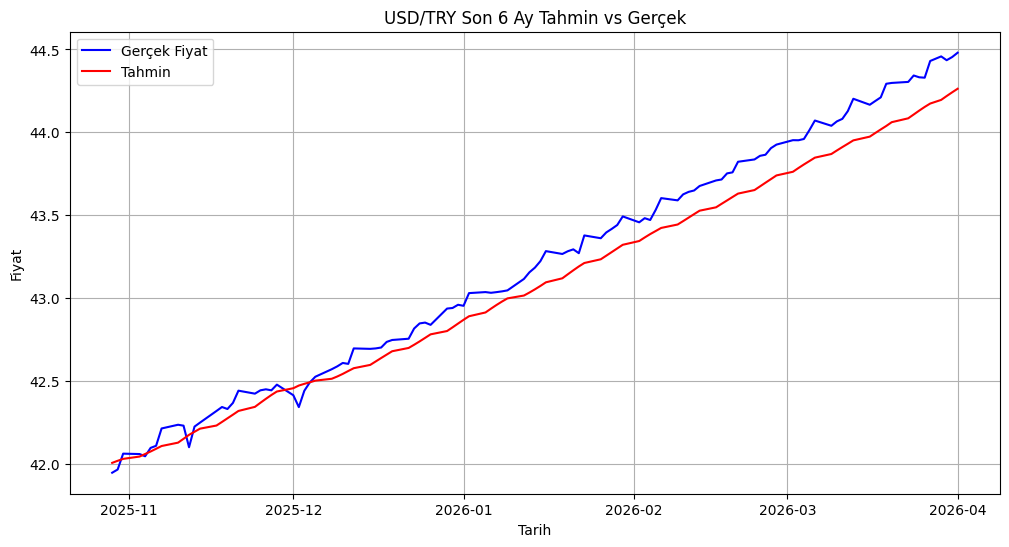

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test.index[window_size:], y_true, label='Gerçek Fiyat', color='blue')
plt.plot(test.index[window_size:], y_pred, label='Tahmin', color='red')
plt.title('USD/TRY Son 6 Ay Tahmin vs Gerçek')
plt.xlabel('Tarih')
plt.ylabel('Fiyat')
plt.legend()
plt.grid(True)
plt.show()

In [97]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

MSE: 0.01931600344196959
MAE: 0.12377192235674224
RMSE: 0.13898202560752088


In [98]:
# Baseline: yarın = bugün
y_baseline = X_test[:, -1, 0].reshape(-1, 1)
y_baseline = scaler.inverse_transform(y_baseline)

from sklearn.metrics import mean_absolute_error
mae_baseline = mean_absolute_error(y_true, y_baseline)

print("Baseline MAE:", mae_baseline)

Baseline MAE: 0.03303125000000019
